<a href="https://colab.research.google.com/github/mchlgho22/Project1_FaceRecognition_GoogleNet/blob/main/FaceRecognition%20-%20GoogleNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
# from torchvision.models import resnet50
from torchvision.models import googlenet, GoogLeNet_Weights
import time
from torch.autograd import Variable
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

In [ ]:
# !rm -rf /content/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = '/content/drive/MyDrive/FaceRecognition/Dataset'
images_path = os.path.join(data_path, 'Images')
attr_path = os.path.join(data_path, 'list_attribute.txt')
model_dir = os.path.join(data_path, "model_saved")
os.makedirs(model_dir, exist_ok=True)
os.listdir(data_path)

print("Dataset Path:",data_path)
print("Model Path:",model_dir)

Dataset Path: /content/drive/MyDrive/FaceRecognition/Dataset
Model Path: /content/drive/MyDrive/FaceRecognition/Dataset/model_saved


In [ ]:
with open(attr_path, 'r') as f:
    lines = f.readlines()

# print(lines) # hasil raw list attribute

In [ ]:
# Cek Attribute Male
attrs = lines[1].split()
print("Male", attrs.index("Male"))

Male 20


In [ ]:
# Parsing Attribute CelebA
with open(attr_path, 'r') as f:
    lines = f.readlines()

# baris ke-2 adalah nama atribut
columns = lines[1].split()

# data mulai baris ke-3
records = []
for line in lines[2:]:
    parts = line.split()
    img = parts[0]
    attrs = list(map(int, parts[1:]))

    male = attrs[20]  # index Male

    gender = 1 if male == 1 else 0
    records.append([img, gender])

data = pd.DataFrame(records, columns=['image', 'gender'])

# filter hanya image yang ada
images_list = os.listdir(images_path)
data = data[data['image'].isin(images_list)]

# gunakan hanya 5000 data
data = data.sample(5000, random_state=42)

print(data.head())

             image  gender
60964   060965.jpg       1
103729  103730.jpg       1
107305  107306.jpg       1
42409   042410.jpg       1
28519   028520.jpg       1


In [ ]:
gender_counts = data['gender'].value_counts()
gender_percentages = data['gender'].value_counts(normalize=True) * 100

male_count = gender_counts.get(1, 0)
female_count = gender_counts.get(0, 0)

male_pct = gender_percentages.get(1, 0)
female_pct = gender_percentages.get(0, 0)

print(f"Male: {male_count} ({male_pct:.2f}%)")
print(f"Female: {female_count} ({female_pct:.2f}%)")

Male: 2047 (40.94%)
Female: 2953 (59.06%)


In [ ]:
# -------------------------------
# Stratified Train/Test Split
# -------------------------------

train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    stratify=data['gender'],
    random_state=42
)

# print("Train Data :",len(train_data))
# print("Test Data :",len(test_data))

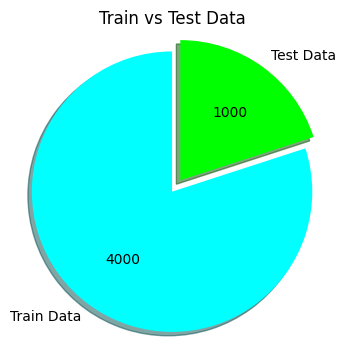

In [ ]:
# -------------------------------
# Jumlah Data Train vs Test
# -------------------------------
train = len(train_set)
test = len(test_set)

labels = ['Train Data', 'Test Data']
sizes = [train, test]
colors = ['aqua', 'lime']
explode = (0.05, 0.05)  # memberi efek terangkat

def show_value(pct):
    total = sum(sizes)
    val = int(pct * total / 100)
    return f'{val}'

plt.figure(figsize=(4,4))
plt.pie(
    sizes,
    labels=labels,
    # autopct='%1.1f%%',
    autopct=show_value,
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=90
)

plt.title('Train vs Test Data')
plt.axis('equal')

plt.show()

## Preprocessing

In [ ]:
class GenderDataset(Dataset):

    def __init__(self, data, image_folder_path, transform=None):
        self.data = data.reset_index(drop=True)
        self.image_folder_path = image_folder_path
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_name = self.data.iloc[idx,0]
        label = self.data.iloc[idx,1]

        img_path = os.path.join(self.image_folder_path, img_name)
        # please define image convertion technique to RGB here
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


In [ ]:
# -------------------------------
# Transforms
# -------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [ ]:
train_set = GenderDataset(train_data,images_path,train_transform)
test_set = GenderDataset(test_data,images_path,test_transform)

train_loader = DataLoader(train_set,batch_size=32,shuffle=True,num_workers=2)
test_loader = DataLoader(test_set,batch_size=32,shuffle=False,num_workers=2)

dataloaders = {
    "train":train_loader,
    "test":test_loader
}

dataset_sizes = {
    "train":len(train_set),
    "test":len(test_set)
}

## Architecture

In [ ]:
print(torch.cuda.is_available())   # True kalau GPU bisa dipakai
print(torch.cuda.get_device_name(0))  # Nama GPU

True
Tesla T4


In [ ]:
# -------------------------------
# Model
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = GoogLeNet_Weights.IMAGENET1K_V1
model = googlenet(weights=weights)

# freeze semua layer
for param in model.parameters():
    param.requires_grad = False

# unfreeze deep layer
for name,param in model.named_parameters():
    if "inception4" in name or "inception5" in name:
        param.requires_grad = True

# ganti classifier
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs,2)
model = model.to(device)

print("Device:",device)


Device: cuda


In [ ]:
# -------------------------------
# Loss & Optimizer
# -------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model.inception4a.parameters(), 'lr': 1e-4},
    {'params': model.inception4b.parameters(), 'lr': 1e-4},
    {'params': model.inception4c.parameters(), 'lr': 1e-4},
    {'params': model.inception4d.parameters(), 'lr': 1e-4},
    {'params': model.inception4e.parameters(), 'lr': 1e-4},
    {'params': model.inception5a.parameters(), 'lr': 1e-4},
    {'params': model.inception5b.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

## Modeling

In [ ]:
# -------------------------------
# Training Function
# -------------------------------
def train_model(model,num_epochs=10):

    since = time.time()
    best_acc = 0.0

    train_loss_history=[]
    test_loss_history=[]

    train_acc_history=[]
    test_acc_history=[]


    for epoch in range(num_epochs):

        print("\nEpoch {}/{}".format(epoch+1,num_epochs))
        print("-"*30)

        for phase in ['train','test']:

            if phase == 'train':
                model.train()
            else:
                model.eval()


            running_loss=0.0
            running_corrects=0


            for inputs,labels in dataloaders[phase]:

                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()


                with torch.set_grad_enabled(phase=='train'):

                    outputs = model(inputs)

                    if hasattr(outputs,"logits"):
                        outputs = outputs.logits

                    loss = criterion(outputs,labels)

                    _,preds = torch.max(outputs,1)


                    if phase=='train':

                        loss.backward()
                        optimizer.step()


                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds==labels.data)


            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]


            print("{} Loss: {:.4f} Acc: {:.4f}".format(
                phase,
                epoch_loss,
                epoch_acc
            ))


            if phase=='train':

                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.cpu().numpy())

            else:

                test_loss_history.append(epoch_loss)
                test_acc_history.append(epoch_acc.cpu().numpy())

                scheduler.step(epoch_loss)

                if epoch_acc > best_acc:

                    best_acc = epoch_acc

                    torch.save(
                        model.state_dict(),
                        os.path.join(model_dir,"best_model.pth")
                    )


    print("\nTraining Complete")
    print("Best Test Accuracy:",best_acc)

    print("Training Time: {:.2f} minutes".format(
        (time.time()-since)/60
    ))


    return (
        model,
        train_loss_history,
        test_loss_history,
        train_acc_history,
        test_acc_history
    )

In [ ]:
# Train Model
model,train_loss,test_loss,train_acc,test_acc = train_model(model,10)


Epoch 1/10
------------------------------
train Loss: 0.2223 Acc: 0.9068
test Loss: 0.1884 Acc: 0.9310

Epoch 2/10
------------------------------
train Loss: 0.1040 Acc: 0.9580
test Loss: 0.1596 Acc: 0.9430

Epoch 3/10
------------------------------
train Loss: 0.0785 Acc: 0.9698
test Loss: 0.1290 Acc: 0.9600

Epoch 4/10
------------------------------
train Loss: 0.0578 Acc: 0.9788
test Loss: 0.1237 Acc: 0.9620

Epoch 5/10
------------------------------
train Loss: 0.0405 Acc: 0.9850
test Loss: 0.1353 Acc: 0.9620

Epoch 6/10
------------------------------
train Loss: 0.0320 Acc: 0.9903
test Loss: 0.1268 Acc: 0.9580

Epoch 7/10
------------------------------
train Loss: 0.0292 Acc: 0.9900
test Loss: 0.1357 Acc: 0.9590

Epoch 8/10
------------------------------
train Loss: 0.0215 Acc: 0.9932
test Loss: 0.1254 Acc: 0.9660

Epoch 9/10
------------------------------
train Loss: 0.0192 Acc: 0.9942
test Loss: 0.1267 Acc: 0.9650

Epoch 10/10
------------------------------
train Loss: 0.0117 A

## Visualisasi Line Graph Training

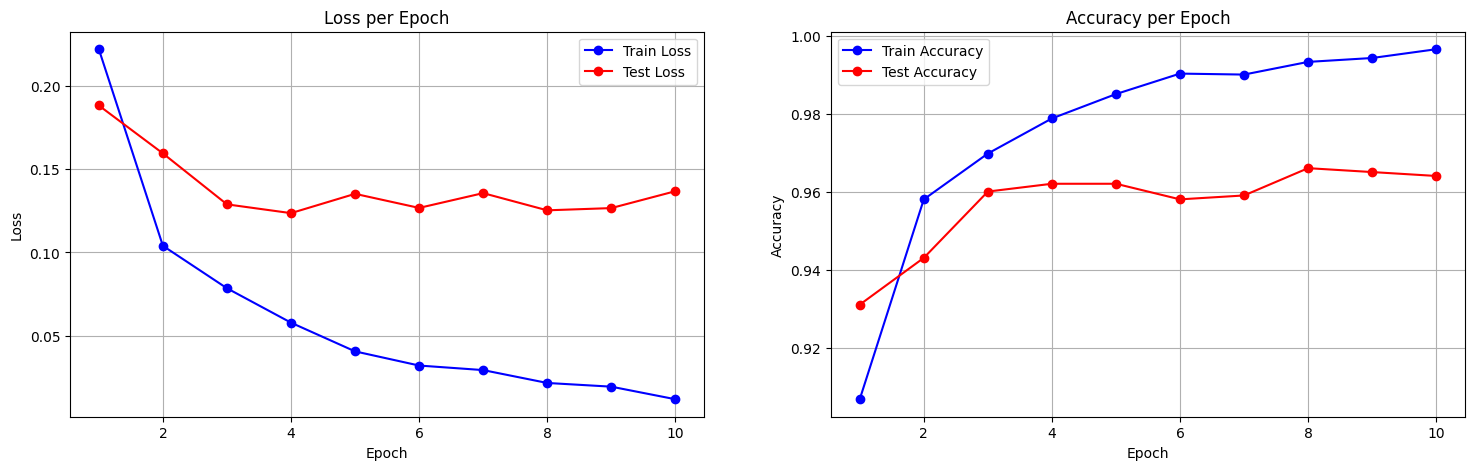

In [ ]:
epochs = range(1, len(train_loss)+1)

plt.figure(figsize=(18, 5))

# Loss Graph
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, 'b-', label='Train Loss', marker='o')
plt.plot(epochs, test_loss, 'r-', label='Test Loss', marker='o')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Accuracy Graph
plt.subplot(1,2,2)
plt.plot(epochs, train_acc, 'b-', label='Train Accuracy', marker='o')
plt.plot(epochs, test_acc, 'r-', label='Test Accuracy', marker='o')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Load Model
model.load_state_dict(torch.load(os.path.join(model_dir,"best_model.pth")))
model.eval()

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

## Evaluation

In [ ]:
def evaluate_model(model, test_loader, target_labels):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            if torch.cuda.is_available():
                images = images.cuda()

            outputs = model(images)

            _, preds = torch.max(outputs,1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("Classification Report")
    print(classification_report(all_labels, all_preds, target_names=target_labels))

    cm = confusion_matrix(all_labels, all_preds)

    print("Confusion Matrix")
    print(cm)

     # Plot Confusion Matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=target_labels,
                yticklabels=target_labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

Classification Report
              precision    recall  f1-score   support

      female       0.97      0.97      0.97       591
        male       0.96      0.95      0.96       409

    accuracy                           0.97      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.97      0.97      0.97      1000

Confusion Matrix
[[576  15]
 [ 19 390]]


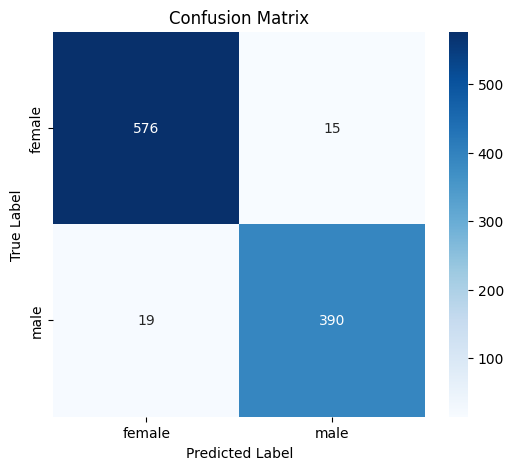

In [ ]:
evaluate_model(model, dataloaders['test'], ["female", "male"])

In [ ]:
import numpy as np

class_names = ["female", "male"]

def visualize_predictions(model, dataloader, num_images=8):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    images_shown = 0
    correct = 0
    total = 0

    fig = plt.figure(figsize=(12,6))

    with torch.no_grad():
        for inputs, labels in dataloader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            # Handle GoogLeNet output if tuple
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            probs = torch.softmax(outputs, dim=1)
            confidences, preds = torch.max(probs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Tampilkan gambar hanya sampai num_images
            for j in range(inputs.size(0)):
                if images_shown < num_images:
                    ax = plt.subplot(2, num_images // 2, images_shown + 1)
                    ax.axis('off')

                    img = inputs[j].cpu().numpy().transpose((1, 2, 0))

                    mean = np.array([0.485, 0.456, 0.406])
                    std = np.array([0.229, 0.224, 0.225])

                    img = std * img + mean
                    img = np.clip(img, 0, 1)

                    ax.imshow(img)

                    true_label = class_names[labels[j].item()]
                    pred_label = class_names[preds[j].item()]

                    color = "green" if preds[j] == labels[j] else "red"
                    confidence = confidences[j].item() * 100

                    ax.set_title(
                        f"Pred: {pred_label} ({confidence:.1f}%)\nTrue: {true_label}",
                        color=color
                    )
                    images_shown += 1

    plt.tight_layout()
    plt.show()

    accuracy = 100 * correct / total
    print(f"Accuracy: {accuracy:.2f}% ({correct}/{total})")

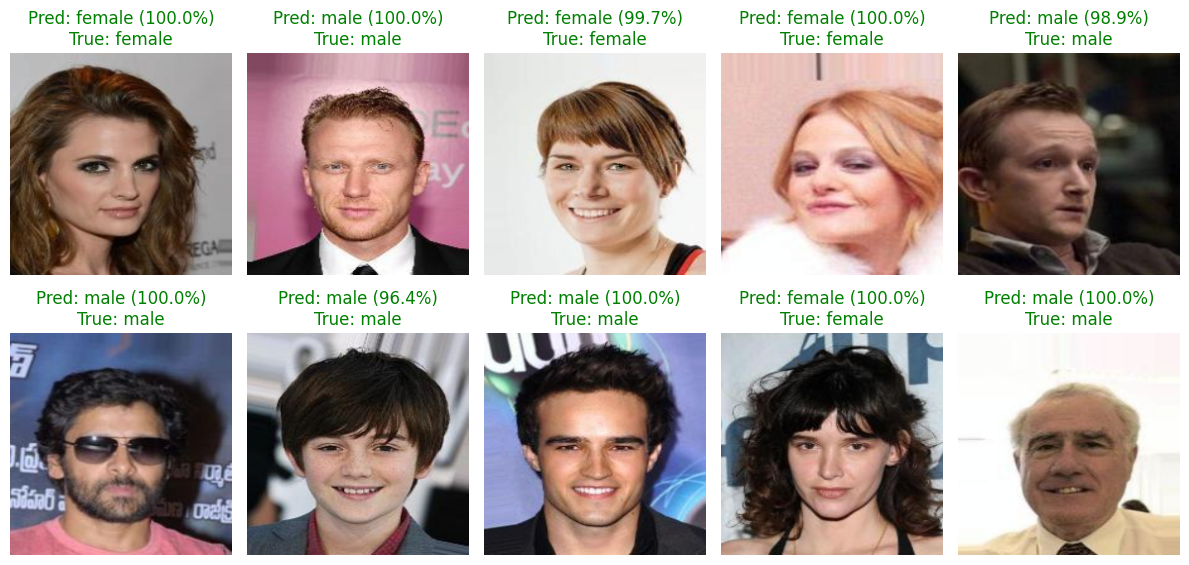

Accuracy: 96.60% (966/1000)


In [ ]:
visualize_predictions(model, test_loader, num_images=10)